In [1]:
!pip install numba
import matplotlib.pyplot as plt
import random
import numpy as np
from numba import jit, prange
from time import time
from numba.typed import List

# Resolução questão 8.13
na primeira celula seguinte eu defino as funções que usei para propagar a avalanche de maneira analoga a solicitada pelo livro mas com algumas modificações, transformando uma matriz NxN num vetor N^2, o que são equivalentes, e ao invés de usar uma função que encontra o número de vizinhos com spin up defini uma função que calcula a soma dos spins dos vizinhos pois é apenas ela que precisamos de fato (apesar de ambas serem equivalente matematicamente, teriamos que contar quantos spins estão pra cima e soma-los, o que não eficiente, visto que podemos somar diretamente)

na segunda defino de fato a função que propaga a avalanche, levando em consideração que possui um vetor representando a matriz.



In [2]:
#creates the initial spin configuration with all spin down#
@jit
def initial_spin(N):
  return np.full((N**2), -1)

def initial_randomfield(N,R):
  h=[]
  for i in range(N**2):
    h.append(random.gauss(0, R))

  return np.array(h, np.float64)


@jit
def initial_spin_cubico(N):
  return np.full((N**3), -1)

def initial_randomfield_cubico(N,R):
  h=[]
  for i in range(N**3):
    h.append(random.gauss(0, R))

  return np.array(h, np.float64)

@jit
def FlipSpin_list(s, v):
  if s[v] == -1 :
    s[v] = 1
  else:
    print("spin already fliped")
@jit
def viz_rede_2d_period(Lx,Ly):
    # Criando uma lista de vizinhos de todos os sítios da rede,
    # respeitando as condições de contorno.
    nviz = 4   # Número de vizinhos de cada sítio na rede unidimensional
    viz = np.empty((Lx*Ly,nviz),dtype=np.int64)
    for x in range(Lx):
        for y in range (Ly):
            v = x + y * Lx
            viz[v, 0] = (x+1)%Lx + y*Lx # Vizinho à direita
            viz[v, 1] = (x-1)%Lx + y*Lx # Vizinho à esquerda
            viz[v, 2] = x + ((y+1)%Ly)*Lx #vizinho encima
            viz[v, 3] = x + ((y-1)%Ly)*Lx #vizinho abaixo
    return nviz, viz

@jit
def sum_spin_list(s, i, viz , nviz):

    N=len(s)
    sum=0
    for n in range(nviz):
      sum+=s[viz[i][n]]
    return sum
@jit
def BruteForceNextAvalanche_list(s,h, viz, nviz):
  #starting point that allow at least one site to have an internal field greater than this value
  max=-np.inf

  for v in range(len(s)):
    #Calculates the internal fiel for each particle#
    internal_field = sum_spin_list(s,v, viz, nviz) + h[v]
    # stores the maximum internal field found
    if internal_field > max and s[v]==-1:
      max = internal_field
      max_v = v

  if max == -1000000:
    print("erro")
    print(s)
    print(s.sum())

  return max, max_v
@jit
def PropagateAvalanche(v_max, h, s, viz, nviz):
  #start the avalanche flipping the first spin, with maximum internal field
  FlipSpin_list(s, v_max)

  #considering the first shell is the spin that triggers the avalanche
  shell_sizes=[1]
  initial_shell = [v_max]

  next_shell = np.empty(0, dtype=np.int64) # To store neighbors for the next shell
  avalanche_size = 1

  while initial_shell: #(5) run until a shell does not flip any other spin
    for current_site in initial_shell:
      for n in range(nviz):
        neighbor = viz[current_site, n] # select each neighbor of a element of a shell
        internal_field_viz = sum_spin_list(s, neighbor, viz, nviz) + h[neighbor] #calculates it's internal field

        if s[neighbor] == -1 and internal_field_viz>0:
        #(4)if the neighbor has positive internal field and was not flipped yet, it
        #must be flipped and added to the next shell
          next_shell = np.append(next_shell, neighbor)
          FlipSpin_list(s, neighbor)
          avalanche_size += 1
    #stores the shell size to be able to do graph like in the figure 8.18 (which doesn't correspond to the same problem)
    #instead of doing as told ind (3) I simple store each shell and after all the sites
    #in the shell had it neighbours searched all the shell is deleted
    shell_sizes.append(len(next_shell))
    initial_shell = list(next_shell) # Update initial_shell with next shell
    next_shell = np.empty(0, dtype=np.int64)  # Reset next_shell for the following layer

  return avalanche_size, shell_sizes




In [3]:
@jit
def simulation(h_initial):
  #creates a copy that will have the value varied by the external field, to work better on numba
  #by storing the initial value
  h=h_initial.copy()
  #defines the size of the system and creates the initial spin lattice
  N = int(np.sqrt(len(h)))
  s=initial_spin(N)
  #calculates the starting magnezation to run the loop and store it
  M= int(np.sum(s))
  M_list = [M]
  avalanche_sizes=[0]
  all_shell_sizes =[]
  nviz, viz = viz_rede_2d_period(N, N)
  total_time = 0

  while M < N**2 :

    max, v_max = BruteForceNextAvalanche_list(s,h, viz, nviz)

    #consider the case where there is starting points with positive internal field (random field > 4)
    # in this case they are flipped (individually each triggering it's own avalanche)
    # but the is no need to increase the external field to flip it
    max_internal_field = sum_spin_list(s, v_max, viz, nviz) + h[v_max]
    if max_internal_field < 0:
      h += -max

    avalanche_size, shell_sizes = PropagateAvalanche(v_max, h, s, viz, nviz)

    for size in shell_sizes:
      all_shell_sizes.append(size)

    avalanche_sizes.append(avalanche_size)
    M = int(np.sum(s))
    M_list.append(M)

  return M_list, avalanche_sizes, all_shell_sizes

# Gerando gráficos para os casos pedidos

Na célula abaixo defino uma lista cujos elementos são os estados iniciais pedidos, com "random field" com desvio padrões, R, iguais a 0.7, 0.9, 1.4 e também 1.1. Além de calcular o tempo de execução, com isso podemos igualar os parâmetros com o algoritmo que ordena os campos aleatórios e comparar o tempo levada para cada um deles.

Na segunda célula abaixo faço um gráfico contendo todos os casos para um comparação dos casos.

Podemos ver que os gráficos se comportam de maneira esperada. Quanto menor o desvio padrão, mais "próximos" serão os valores do campo aleatório, fazendo que com quando tempo suficiente passe o campo externo aumente, a soma do campo aleatório com campo externo seja próxima de 0 para muitos sitios. Logo ao inverter um spin, temos avalanches maiores invertando a maioria dos sitios de uma vez.

Já para os desvio padrões maiores temos avalanches menores e gerando um  número maior de avalanches


In [4]:
R=[0.7 , 0.9, 1.1, 1.4]
N=200

h=[]
for i in range(len(R)):
  h.append(initial_randomfield(N, R[i]))

a=[]
b=[]
c=[]
for j in range(len(h)):
    aux = time()
    a1 , b1, c1 = simulation(h[j])
    print(j+1,'° simulation completed')
    print("Tempo de execução em segundos =",time()-aux)
    a.append(a1)
    b.append(b1)
    c.append(c1)

1 ° simulation completed
Tempo de execução em segundos = 13.049100399017334
2 ° simulation completed
Tempo de execução em segundos = 0.1363661289215088
3 ° simulation completed
Tempo de execução em segundos = 0.4307272434234619
4 ° simulation completed
Tempo de execução em segundos = 1.019991159439087


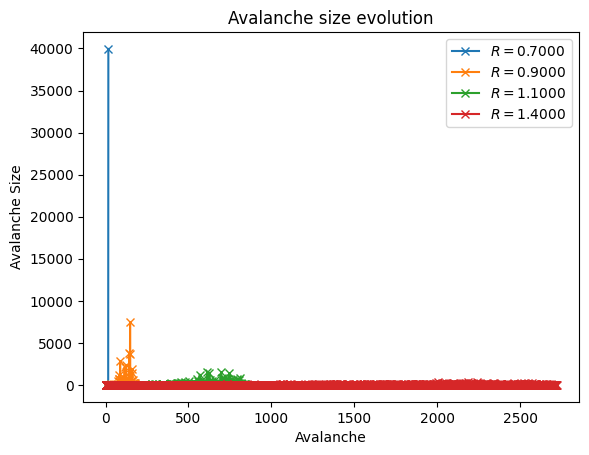

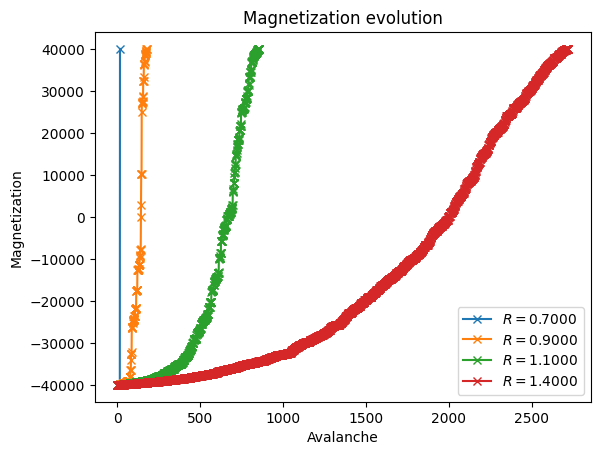

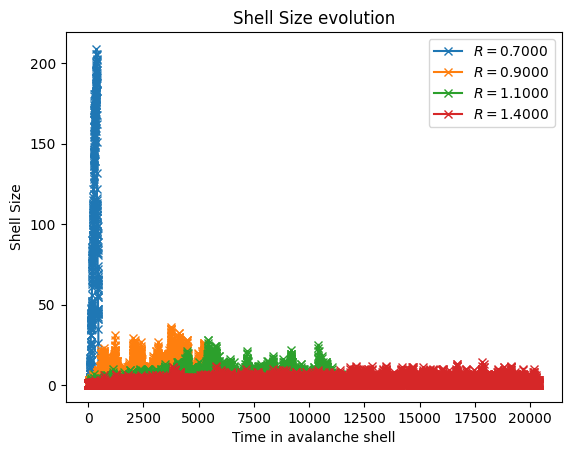

In [5]:

# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Avalanche Size')
plt.title('Avalanche size evolution')
for j in range(len(b)):
  b_x = list(range(1, len(b[j])+1))
  plt.plot(b_x,b[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Magnetization')

plt.title('Magnetization evolution')
for j in range(len(b)):
  a_x = list(range(1, len(a[j])+1))
  plt.plot(a_x,a[j],'-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Time in avalanche shell')
plt.ylabel('Shell Size')
plt.title('Shell Size evolution')
for j in range(len(c)):
  c_x = list(range(1, len(c[j])+1))
  plt.plot(c_x,c[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()




# Resolução Exercício 8.14

Aqui implemento a modificação na simulação, que recebe a lista ordenada e faz uma busca mais inteligente do próximo ponto a gerar uma avalanche sem usar a função BruteForceNextAvalanche e usando as outras funções criadas anteriormente

Apesar do exercício pedir inicialmente para criar uma função que conta os números de spin pra cima (e creio que aqui seria local em que ele seria melhor utilizada logo anteriormente a etapa (4)), é direto a transformação da soma de spin para essa quantidade, assim uso apenas a função que defini.

In [6]:
@jit
#here use the sorted list as a input because creating it inside the loop generates a problem with numba
def simulation_sorted(h_initial, sorted_list):
  #creates a copy that will have the value varied by the external field, to work better on numba
  #by storing the initial value
  h=h_initial.copy()

  #Size of h is N**2
  N = int(np.sqrt(len(h)))
  #creates the initial spin lattice
  s=initial_spin(N)
  #calculate the initial magnetization -N**2 to start the loop
  M= int(np.sum(s))

  M_list=[M]
  avalanche_sizes=[0]
  all_shell_sizes =[]
  nviz, viz = viz_rede_2d_period(N, N)

  # Initialize nextPossible array pointing to the starting point of the sorted list
  nextPossible = np.zeros(nviz+1, dtype=np.int64)
  stopNUP= nviz

  while M < N**2:
    # Step 2: Choose spin with largest internal field
    max = -np.inf
    #(2) select from nextPossible the one with highest internal field
    for nUp in range(stopNUP+1):
      site= sorted_list[nextPossible[nUp]]
      internal_field = 2*nUp - nviz + h[site]
      if internal_field > max:
        max = internal_field
        nUpNext = nUp
        v_max = site
    #(3) move the pointer to the next spin on the sorted list
    nextPossible[nUpNext] += 1
    #uses the fact the elements of nextPossible fall of the list first from the end
    #the first is nUp=4 then nUp=3 and so on
    if nextPossible[nUpNext] >= len(sorted_list):
      stopNUP -= 1
    #calculates the number of spin Up neighbours from sum_spin
    nUp_neighbours = (nviz + sum_spin_list(s, v_max, viz, nviz))//2
    #(4) check condition to start avalanche, if it doesn't since M won't change
    #it will go back to (2)
    if nUp_neighbours == nUpNext:

      max_internal_field = sum_spin_list(s, v_max, viz, nviz) + h[v_max]
      if max_internal_field < 0:
        h += -max_internal_field

      # Propagate avalanche (using your existing PropagateAvalanche function)
      avalanche_size, shell_sizes = PropagateAvalanche(v_max, h, s, viz, nviz)

      # Update magnetization, avalanche sizes, and shell sizes
      M = int(np.sum(s))
      M_list.append(M)
      avalanche_sizes.append(avalanche_size)
      all_shell_sizes.extend(shell_sizes)

  return M_list, avalanche_sizes, all_shell_sizes

# Gerando gráficos para os outros casos pedidos

Aqui faço analogamente ao que foi feito antes para o casos de força bruta, calculando tempo que é levado para ordenar a lista e realizar a simulação para comparar com o algoritmo anterior, além de gerar os mesmo gráficos

In [7]:
R = [0.7, 0.8, 0.9]
N = 2000

h = []
for i in range(len(R)):
  h.append(initial_randomfield(N, R[i]))

a_sorted = []
b_sorted = []
c_sorted = []
for j in range(len(h)):
  aux = time()
  # Create sorted_list outside the loop and pass it to simulation_sorted
  sorted_list = sorted(range(len(h[j])), key=lambda k: -h[j][k])
  print("Tempo de ordenação lista em segundos =", time() - aux)
  a1, b1, c1 = simulation_sorted(h[j], sorted_list)
  print(j + 1, '° simulation completed')
  print("Tempo de execução em segundos =", time() - aux)
  a_sorted.append(a1)
  b_sorted.append(b1)
  c_sorted.append(c1)

Tempo de ordenação lista em segundos = 6.6455395221710205
1 ° simulation completed
Tempo de execução em segundos = 31.066255569458008
Tempo de ordenação lista em segundos = 8.078425645828247
2 ° simulation completed
Tempo de execução em segundos = 63.172287702560425
Tempo de ordenação lista em segundos = 8.20835256576538
3 ° simulation completed
Tempo de execução em segundos = 184.2340440750122


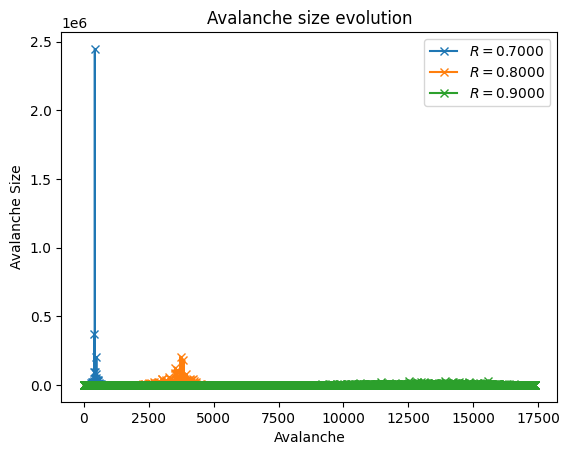

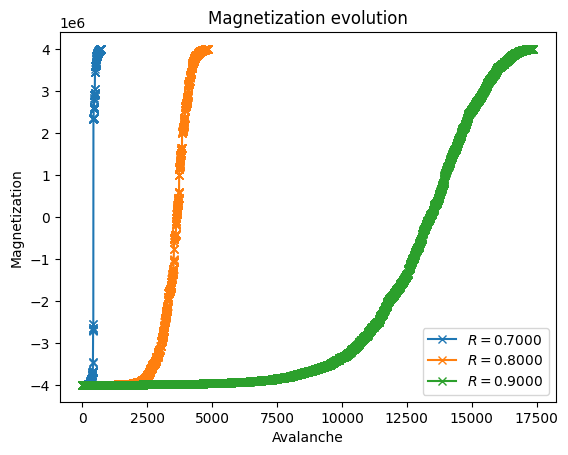

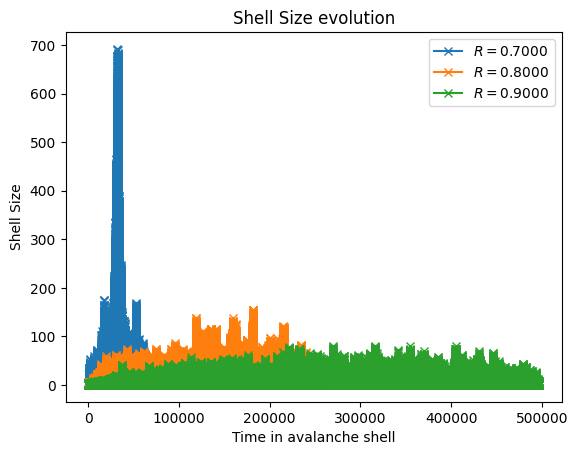

In [8]:

# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Avalanche Size')
plt.title('Avalanche size evolution')
for j in range(len(b_sorted)):
  b_x = list(range(1, len(b_sorted[j])+1))
  plt.plot(b_x,b_sorted[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Magnetization')

plt.title('Magnetization evolution')
for j in range(len(a_sorted)):
  a_x = list(range(1, len(a_sorted[j])+1))
  plt.plot(a_x,a_sorted[j],'-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Time in avalanche shell')
plt.ylabel('Shell Size')
plt.title('Shell Size evolution')
for j in range(len(c_sorted)):
  c_x = list(range(1, len(c_sorted[j])+1))
  plt.plot(c_x,c_sorted[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()

# Testes
Na célula abaixo testo meu algoritmo de propagação da avalanche afim de comparar com o exemplo dado na Figura 8.17 do livro, gerando um exemplo no qual deveria apresentar uma propagação indêntica  

Na próxima célula eu comparo as duas simulações para ver que para um mesmo inicializando as simulações com um mesmo campo aletório temos a mesma evolução

In [9]:
s=initial_spin(5)
h = [-5.0, -5.0 ,-5.0 , -5.0, -5.0,
     0.1, 0.11, 2.05, -6.0, 2.06,
     3.01, 2.57, 4.0, 2.98, 3.5,
     -10.0, 2.67, -1.5, 3.6, 0.5,
     -5.0, -5.0, -5.0, -5.0, -5.0]
nviz, viz= viz_rede_2d_period(5,5)

PropagateAvalanche(12, h, s, viz, nviz)

(13, [1, 3, 5, 4, 0])

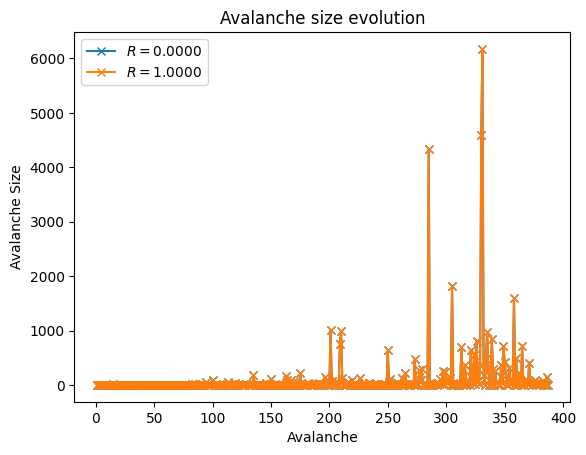

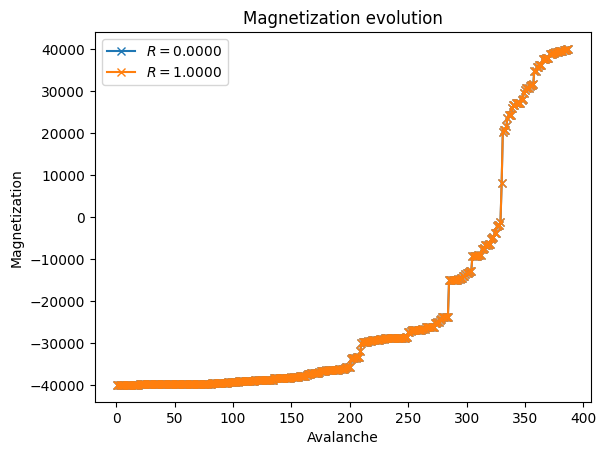

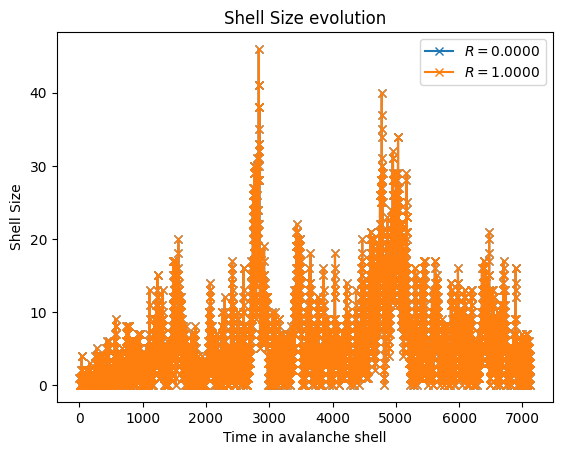

In [10]:
h=initial_randomfield(200, 1)
sorted_list = sorted(range(len(h)), key=lambda k: -h[k])

a_n, b_n, c_n = simulation(h)
a_s, b_s, c_s = simulation_sorted(h, sorted_list)

a=[a_n, a_s]
b=[b_n, b_s]
c=[c_n, c_s]

# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Avalanche Size')
plt.title('Avalanche size evolution')
for j in range(len(b)):
  b_x = list(range(1, len(b[j])+1))
  plt.plot(b_x,b[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(j))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Magnetization')

plt.title('Magnetization evolution')
for j in range(len(b)):
  a_x = list(range(1, len(a[j])+1))
  plt.plot(a_x,a[j],'-x',\
               label=r"$R = $"+'{:6.4f}'.format(j))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Time in avalanche shell')
plt.ylabel('Shell Size')
plt.title('Shell Size evolution')
for j in range(len(c)):
  c_x = list(range(1, len(c[j])+1))
  plt.plot(c_x,c[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(j))
# Display the plot
plt.legend()
plt.show()



# Outras geometrias
Cùbica, triangular e hexagonal como usadas em aula. A matrix que define os vizinhos esta definida na célula abaixo.

Na posterior defino as simulações para cada geometria mudando apenas a função que chama os vizinhos do algoritmo ordenado, pois se mostrou mais rápido.

E para testar para mais valores de R defino um simulação em lotes que testa para diversos valores R de uma vez só usando paralelização.




In [11]:
#geometria hexagonal
@jit
def viz_rede_hex_period(Lx,Ly):
    # Criando uma lista de vizinhos de todos os sítios da rede,
    # respeitando as condições de contorno.
    nviz = 3   # Número de vizinhos de cada sítio na rede quadrada
    viz = np.empty((Lx*Ly,3),dtype=np.int64)
    for y in range(Ly):
        for x in range(Lx):
            v = x + y*Lx   # Sítio cujos vizinhos vamos registrar
            viz[v,0] = (x+1)%Lx + y*Lx   # Vizinho à direita
            viz[v,1] = (x-1)%Lx + y*Lx   # Vizinho à esquerda
            if x%2==0:
              if y%2 == 0:
                viz[v,2] = x + ((y+1)%Ly)*Lx # Vizinho acima
              else:
                viz[v,2] = x + ((y-1)%Ly)*Lx # Vizinho abaixo

            elif x%2 != 0:
              if y%2 == 0:
                viz[v,2] = x + ((y-1)%Ly)*Lx # Vizinho abaixo
              else:
                viz[v,2] = x + ((y+1)%Ly)*Lx # Vizinho acima

    return nviz, viz

#geometria triangular
@jit
def viz_rede_triangular_period(Lx,Ly):
    # Criando uma lista de vizinhos de todos os sítios da rede,
    # respeitando as condições de contorno.
    nviz = 6   # Número de vizinhos de cada sítio na rede triangular
    viz = np.full((Lx*Ly,6),-1,dtype=np.int64)
    for y in range(Ly):
        for x in range(Lx):
            v = x + y*Lx   # Sítio cujos vizinhos vamos registrar

            viz[v,0] = (x+1)%Lx + y*Lx         # Vizinho à direita
            viz[v,1] = x + ((y+1)%Ly)*Lx         # Vizinho acima
            viz[v,2] = (x-1)%Lx + ((y-1)%Ly)*Lx        # Vizinho à diagonal inferior
            viz[v,3] = (x-1)%Lx + y*Lx         # Vizinho à esquerda
            viz[v,4] = x  + ((y-1)%Ly)*Lx         # Vizinho abaixo
            viz[v,5] = (x+1)%Lx + ((y+1)%Ly)*Lx         # Vizinho à diagonal superior

    return nviz, viz

#geometria cúbica
@jit
def viz_rede_cubico_period(Lx,Ly,Lz):
# Criando uma lista de vizinhos de todos os sítios da rede,
# respeitando as condições de contorno.
    nviz = 6   # Número de vizinhos de cada sítio na rede quadrada
    viz = np.empty((Lx*Ly*Lz,6),dtype=np.int64)
    for y in range(Ly):
        for x in range(Lx):
          for z in range(Lz):
            v = x + y*Lx + z*Ly*Lz  # Sítio cujos vizinhos vamos registrar
            viz[v,0] = (x+1)%Lx + y*Lx + z*Ly*Lz   # Vizinho à direita
            viz[v,1] = x + ((y+1)%Ly)*Lx + z*Ly*Lz # Vizinho abaixo
            viz[v,2] = (x-1)%Lx + y*Lx + z*Ly*Lz  # Vizinho à esquerda
            viz[v,3] = x + ((y-1)%Ly)*Lx + z*Ly*Lz # Vizinho acima
            viz[v,4] = x + y*Lx + ((z+1)%Lz)*Ly*Lz  # Vizinho à frente
            viz[v,5] = x + y*Lx + ((z-1)%Lz)*Ly*Lz # Vizinho atras
    return nviz, viz

In [12]:
@jit
#here use the sorted list as a input because creating it inside the loop generates a problem with numba
def simulation_sorted_hexagonal(h_initial, sorted_list):
  #creates a copy that will have the value varied by the external field, to work better on numba
  #by storing the initial value
  h=h_initial.copy()

  #Size of h is N**2
  N = int(np.sqrt(len(h)))
  #creates the initial spin lattice
  s=initial_spin(N)
  #calculate the initial magnetization -N**2 to start the loop
  M= int(np.sum(s))

  M_list=[M]
  avalanche_sizes=[0]
  all_shell_sizes =[]
  nviz, viz = viz_rede_hex_period(N,N)

  # Initialize nextPossible array pointing to the starting point of the sorted list
  nextPossible = np.zeros(nviz+1, dtype=np.int64)
  stopNUP = nviz

  while M < N**2:
    # Step 2: Choose spin with largest internal field
    max = -np.inf
    #(2) select from nextPossible the one with highest internal field
    for nUp in range(stopNUP+1):
      site= sorted_list[nextPossible[nUp]]
      internal_field = 2*nUp - nviz + h[site]
      if internal_field > max:
        max = internal_field
        nUpNext = nUp
        v_max = site
    #(3) move the pointer to the next spin on the sorted list
    nextPossible[nUpNext] += 1
    #uses the fact the elements of nextPossible fall of the list first from the end
    #the first is nUp=4 then nUp=3 and so on
    if nextPossible[nUpNext] >= len(sorted_list):
      stopNUP -= 1

    #calculates the number of spin Up neighbours from sum_spin
    nUp_neighbours = (nviz + sum_spin_list(s, v_max, viz, nviz))//2
    #(4) check condition to start avalanche, if it doesn't since M won't change
    #it will go back to (2)
    if nUp_neighbours == nUpNext and s[v_max]==-1:

      max_internal_field = sum_spin_list(s, v_max, viz, nviz) + h[v_max]
      if max_internal_field < 0:
        h += -max_internal_field

      # Propagate avalanche (using your existing PropagateAvalanche function)
      avalanche_size, shell_sizes = PropagateAvalanche(v_max, h, s, viz, nviz)

      # Update magnetization, avalanche sizes, and shell sizes
      M = int(np.sum(s))
      M_list.append(M)
      avalanche_sizes.append(avalanche_size)
      all_shell_sizes.extend(shell_sizes)

  return M_list, avalanche_sizes, all_shell_sizes



#here use the sorted list as a input because creating it inside the loop generates a problem with numba
def simulation_sorted_triangular(h_initial, sorted_list):
  #creates a copy that will have the value varied by the external field, to work better on numba
  #by storing the initial value
  h=h_initial.copy()

  #Size of h is N**2
  N = int(np.sqrt(len(h)))
  #creates the initial spin lattice
  s=initial_spin(N)
  #calculate the initial magnetization -N**2 to start the loop
  M= int(np.sum(s))

  M_list=[M]
  avalanche_sizes=[0]
  all_shell_sizes =[]
  nviz, viz = viz_rede_triangular_period(N,N)

  # Initialize nextPossible array pointing to the starting point of the sorted list
  nextPossible = np.zeros(nviz+1, dtype=np.int64)
  stopNUP = nviz

  while M < N**2:
    # Step 2: Choose spin with largest internal field
    max = -np.inf
    #(2) select from nextPossible the one with highest internal field
    for nUp in range(stopNUP+1):
      site= sorted_list[nextPossible[nUp]]
      internal_field = 2*nUp - nviz + h[site]
      if internal_field > max:
        max = internal_field
        nUpNext = nUp
        v_max = site
    #(3) move the pointer to the next spin on the sorted list
    nextPossible[nUpNext] += 1
    #uses the fact the elements of nextPossible fall of the list first from the end
    #the first is nUp=4 then nUp=3 and so on
    if nextPossible[nUpNext] >= len(sorted_list):
      stopNUP -= 1

    #calculates the number of spin Up neighbours from sum_spin
    nUp_neighbours = (nviz + sum_spin_list(s, v_max, viz, nviz))//2
    #(4) check condition to start avalanche, if it doesn't since M won't change
    #it will go back to (2)
    if nUp_neighbours == nUpNext and s[v_max]==-1:

      max_internal_field = sum_spin_list(s, v_max, viz, nviz) + h[v_max]
      if max_internal_field < 0:
        h += -max_internal_field

      # Propagate avalanche (using your existing PropagateAvalanche function)
      avalanche_size, shell_sizes = PropagateAvalanche(v_max, h, s, viz, nviz)

      # Update magnetization, avalanche sizes, and shell sizes
      M = int(np.sum(s))
      M_list.append(M)
      avalanche_sizes.append(avalanche_size)
      all_shell_sizes.extend(shell_sizes)

  return M_list, avalanche_sizes, all_shell_sizes





#here use the sorted list as a input because creating it inside the loop generates a problem with numba
def simulation_sorted_cubico(h_initial, sorted_list,N):
  #creates a copy that will have the value varied by the external field, to work better on numba
  #by storing the initial value
  h=h_initial.copy()

  #creates the initial spin lattice
  s=initial_spin_cubico(N)
  #calculate the initial magnetization -N**2 to start the loop
  M= int(np.sum(s))

  M_list=[M]
  avalanche_sizes=[0]
  all_shell_sizes =[]
  nviz, viz = viz_rede_cubico_period(N,N,N)

  # Initialize nextPossible array pointing to the starting point of the sorted list
  nextPossible = np.zeros(nviz+1, dtype=np.int64)
  stopNUP = nviz

  while M < N**3:
    # Step 2: Choose spin with largest internal field
    max = -np.inf
    #(2) select from nextPossible the one with highest internal field
    for nUp in range(stopNUP+1):
      site= sorted_list[nextPossible[nUp]]
      internal_field = 2*nUp - nviz + h[site]
      if internal_field > max:
        max = internal_field
        nUpNext = nUp
        v_max = site
    #(3) move the pointer to the next spin on the sorted list
    nextPossible[nUpNext] += 1
    #uses the fact the elements of nextPossible fall of the list first from the end
    #the first is nUp=4 then nUp=3 and so on
    if nextPossible[nUpNext] >= len(sorted_list):
      stopNUP -= 1


    #calculates the number of spin Up neighbours from sum_spin
    nUp_neighbours = (nviz + sum_spin_list(s, v_max, viz, nviz))//2
    #(4) check condition to start avalanche, if it doesn't since M won't change
    #it will go back to (2)
    if nUp_neighbours == nUpNext and s[v_max]==-1:

      max_internal_field = sum_spin_list(s, v_max, viz, nviz) + h[v_max]
      if max_internal_field < 0:
        h += -max_internal_field

      # Propagate avalanche (using your existing PropagateAvalanche function)
      avalanche_size, shell_sizes = PropagateAvalanche(v_max, h, s, viz, nviz)

      # Update magnetization, avalanche sizes, and shell sizes
      M = int(np.sum(s))
      M_list.append(M)
      avalanche_sizes.append(avalanche_size)
      all_shell_sizes.extend(shell_sizes)

  return M_list, avalanche_sizes, all_shell_sizes



# Hexagonal

Executando as simulações e gerando os gráficos para um sistema de tamanho 200^2 vemos que o R crítico se encontra relativamente próximo a 0.7 ao notar a mudança de comportamento entre menos avalanches com avalanches maiores e mais avalanches e avalanches menores.


Tempo de ordenação lista em segundos = 0.07497406005859375
1 ° simulation completed
Tempo de execução em segundos = 4.692572593688965
Tempo de ordenação lista em segundos = 0.08022379875183105
2 ° simulation completed
Tempo de execução em segundos = 0.34413862228393555
Tempo de ordenação lista em segundos = 0.08308935165405273
3 ° simulation completed
Tempo de execução em segundos = 0.35341978073120117
Tempo de ordenação lista em segundos = 0.0687417984008789
4 ° simulation completed
Tempo de execução em segundos = 0.31993603706359863
Tempo de ordenação lista em segundos = 0.08253908157348633
5 ° simulation completed
Tempo de execução em segundos = 0.36260223388671875


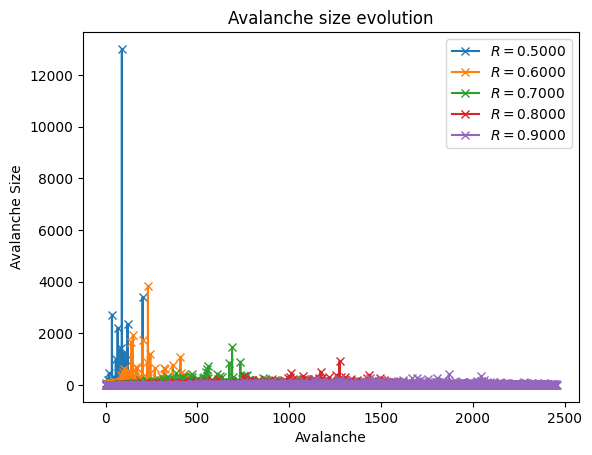

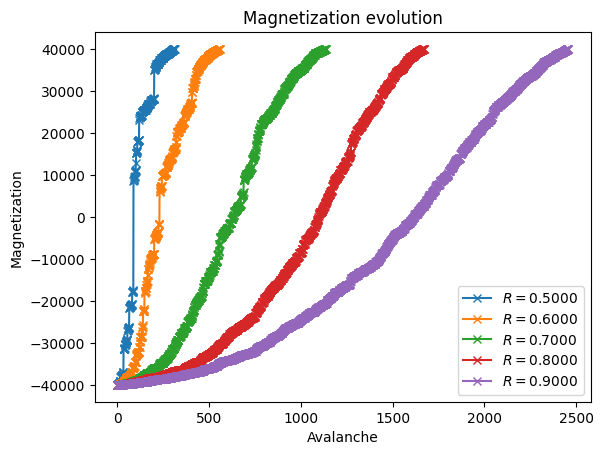

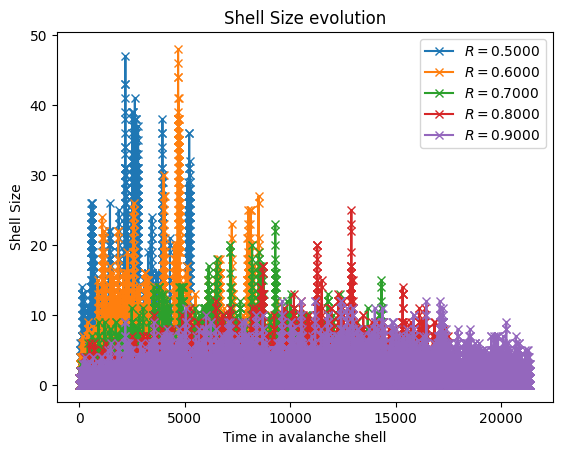

In [13]:
R = [0.5, 0.6, 0.7, 0.8, 0.9]
N = 200

h = []
for i in range(len(R)):
  h.append(initial_randomfield(N, R[i]))

a_sorted = []
b_sorted = []
c_sorted = []
for j in range(len(h)):
  aux = time()
  # Create sorted_list outside the loop and pass it to simulation_sorted
  sorted_list = sorted(range(len(h[j])), key=lambda k: -h[j][k])
  print("Tempo de ordenação lista em segundos =", time() - aux)
  a1, b1, c1 = simulation_sorted_hexagonal(h[j], sorted_list)
  print(j + 1, '° simulation completed')
  print("Tempo de execução em segundos =", time() - aux)
  a_sorted.append(a1)
  b_sorted.append(b1)
  c_sorted.append(c1)


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Avalanche Size')
plt.title('Avalanche size evolution')
for j in range(len(b_sorted)):
  b_x = list(range(1, len(b_sorted[j])+1))
  plt.plot(b_x,b_sorted[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Magnetization')

plt.title('Magnetization evolution')
for j in range(len(a_sorted)):
  a_x = list(range(1, len(a_sorted[j])+1))
  plt.plot(a_x,a_sorted[j],'-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Time in avalanche shell')
plt.ylabel('Shell Size')
plt.title('Shell Size evolution')
for j in range(len(c_sorted)):
  c_x = list(range(1, len(c_sorted[j])+1))
  plt.plot(c_x,c_sorted[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()

# Triangular


Executando as simulações e gerando os gráficos para um sistema de tamanho 200^2 vemos que o R crítico se encontra relativamente próximo a 1.8 ao notar a mudança de comportamento entre menos avalanches com avalanches maiores e mais avalanches e avalanches menores.

1 ° simulation completed
Tempo de execução em segundos = 4.569379568099976
2 ° simulation completed
Tempo de execução em segundos = 2.364785671234131
3 ° simulation completed
Tempo de execução em segundos = 2.4117839336395264
4 ° simulation completed
Tempo de execução em segundos = 2.75101900100708
5 ° simulation completed
Tempo de execução em segundos = 3.1239230632781982


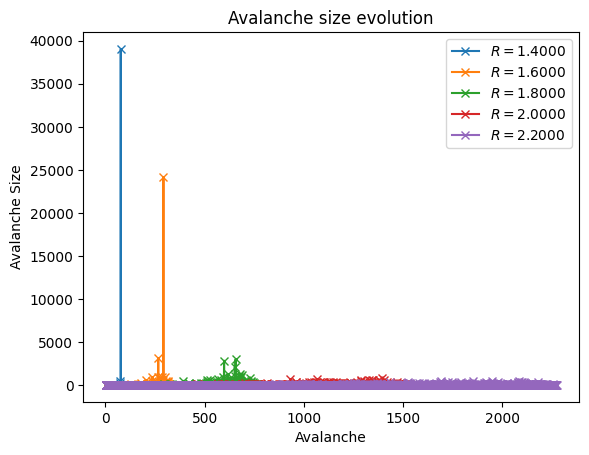

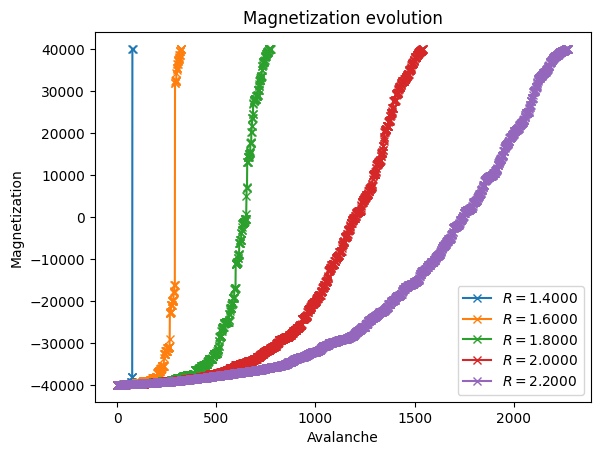

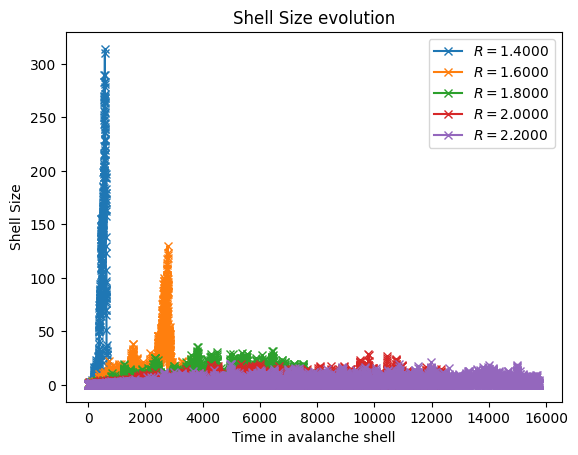

In [14]:
R = [1.4, 1.6, 1.8, 2, 2.2]
N = 200

h = []
for i in range(len(R)):
  h.append(initial_randomfield(N, R[i]))

a_sorted = []
b_sorted = []
c_sorted = []
for j in range(len(h)):
  aux = time()
  # Create sorted_list outside the loop and pass it to simulation_sorted
  sorted_list = sorted(range(len(h[j])), key=lambda k: -h[j][k])
  a1, b1, c1 = simulation_sorted_triangular(h[j], sorted_list)
  print(j + 1, '° simulation completed')
  print("Tempo de execução em segundos =", time() - aux)
  a_sorted.append(a1)
  b_sorted.append(b1)
  c_sorted.append(c1)


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Avalanche Size')
plt.title('Avalanche size evolution')
for j in range(len(b_sorted)):
  b_x = list(range(1, len(b_sorted[j])+1))
  plt.plot(b_x,b_sorted[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Magnetization')

plt.title('Magnetization evolution')
for j in range(len(a_sorted)):
  a_x = list(range(1, len(a_sorted[j])+1))
  plt.plot(a_x,a_sorted[j],'-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Time in avalanche shell')
plt.ylabel('Shell Size')
plt.title('Shell Size evolution')
for j in range(len(c_sorted)):
  c_x = list(range(1, len(c_sorted[j])+1))
  plt.plot(c_x,c_sorted[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()

# Cúbico

Executando as simulações e gerando os gráficos para um sistema de tamanho 50^3 vemos que o R crítico se encontra relativamente próximo a 2.4 ao notar a mudança de comportamento entre menos avalanches com avalanches maiores e mais avalanches e avalanches menores.


1 ° simulation completed
Tempo de execução em segundos = 4.600204944610596
2 ° simulation completed
Tempo de execução em segundos = 6.030599355697632
3 ° simulation completed
Tempo de execução em segundos = 5.524238109588623
4 ° simulation completed
Tempo de execução em segundos = 7.064898252487183
5 ° simulation completed
Tempo de execução em segundos = 6.166173219680786


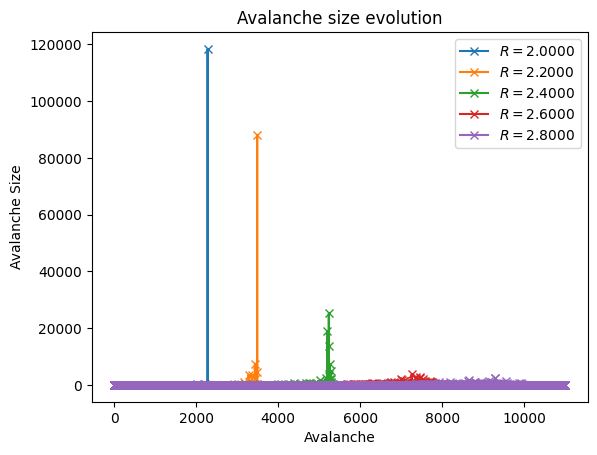

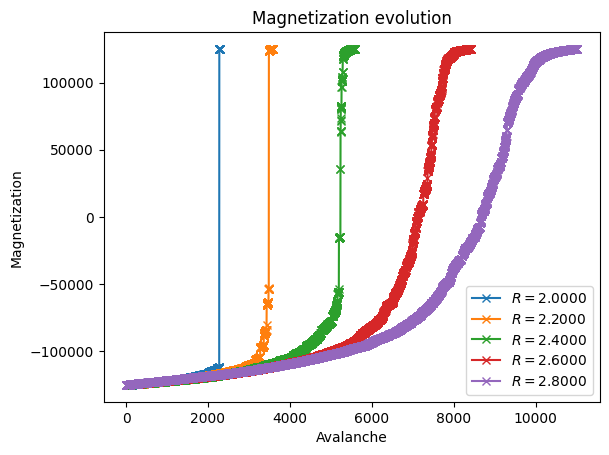

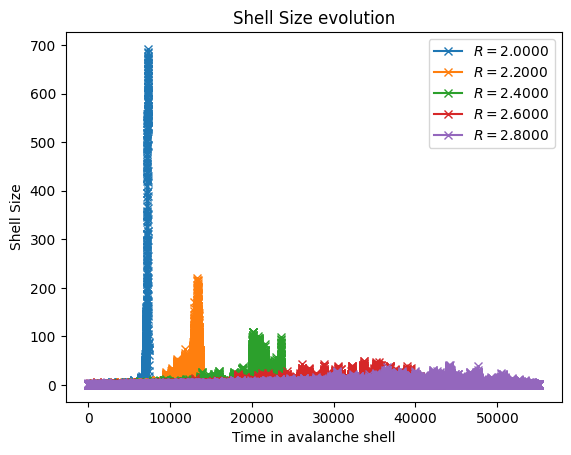

In [15]:
R = [2, 2.2, 2.4, 2.6, 2.8]
N = 50

h = []
for i in range(len(R)):
  h.append(initial_randomfield_cubico(N, R[i]))

a_sorted = []
b_sorted = []
c_sorted = []
for j in range(len(h)):
  aux = time()
  # Create sorted_list outside the loop and pass it to simulation_sorted
  sorted_list = sorted(range(len(h[j])), key=lambda k: -h[j][k])
  a1, b1, c1 = simulation_sorted_cubico(h[j], sorted_list, N)
  print(j + 1, '° simulation completed')
  print("Tempo de execução em segundos =", time() - aux)
  a_sorted.append(a1)
  b_sorted.append(b1)
  c_sorted.append(c1)


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Avalanche Size')
plt.title('Avalanche size evolution')
for j in range(len(b_sorted)):
  b_x = list(range(1, len(b_sorted[j])+1))
  plt.plot(b_x,b_sorted[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Magnetization')

plt.title('Magnetization evolution')
for j in range(len(a_sorted)):
  a_x = list(range(1, len(a_sorted[j])+1))
  plt.plot(a_x,a_sorted[j],'-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Time in avalanche shell')
plt.ylabel('Shell Size')
plt.title('Shell Size evolution')
for j in range(len(c_sorted)):
  c_x = list(range(1, len(c_sorted[j])+1))
  plt.plot(c_x,c_sorted[j], '-x',\
               label=r"$R = $"+'{:6.4f}'.format(R[j]))
# Display the plot
plt.legend()
plt.show()

# Influência do tamanho do sistema no valor crítico

Vemos que o tamanho das avalanches muda muito pouco com o tamanho do sistema e menos ainda o tamanho das camadas, apenas apresentando mais avalanches o que é esperado, pois sendo o tamanho do sistema maior leva-se mais tempo para inverter todos os spins. O que nos leva a concluir que o valor crítico depende unicamente da geometria, como esperado.

1 ° simulation completed
Tempo de execução em segundos = 0.04157662391662598
2 ° simulation completed
Tempo de execução em segundos = 0.08799004554748535
3 ° simulation completed
Tempo de execução em segundos = 0.1767263412475586
4 ° simulation completed
Tempo de execução em segundos = 0.3399980068206787
5 ° simulation completed
Tempo de execução em segundos = 0.6685090065002441


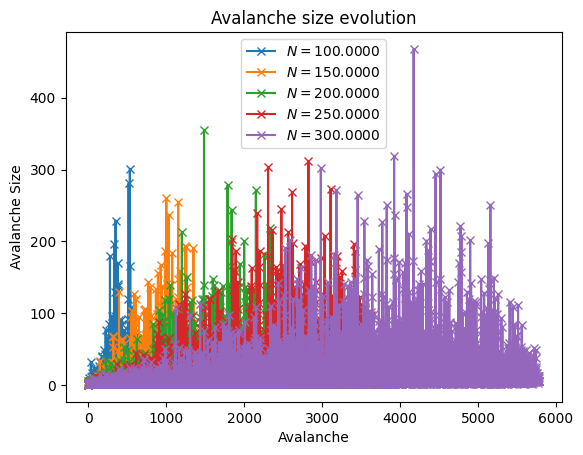

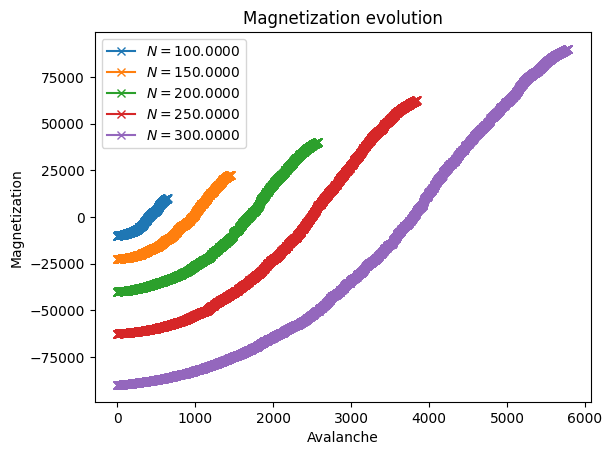

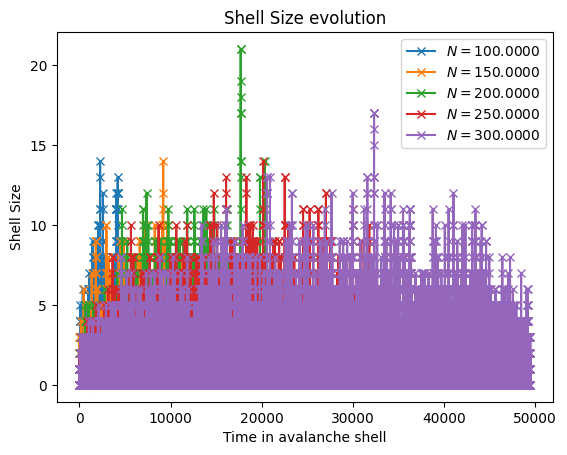

In [16]:
R = 0.9
N = [100,150, 200, 250, 300]

h = []
for i in range(len(N)):
  h.append(initial_randomfield(N[i], R))

a_sorted = []
b_sorted = []
c_sorted = []
for j in range(len(h)):
  aux = time()
  # Create sorted_list outside the loop and pass it to simulation_sorted
  sorted_list = sorted(range(len(h[j])), key=lambda k: -h[j][k])
  a1, b1, c1 = simulation_sorted_hexagonal(h[j], sorted_list)
  print(j + 1, '° simulation completed')
  print("Tempo de execução em segundos =", time() - aux)
  a_sorted.append(a1)
  b_sorted.append(b1)
  c_sorted.append(c1)


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Avalanche Size')
plt.title('Avalanche size evolution')
for j in range(len(b_sorted)):
  b_x = list(range(1, len(b_sorted[j])+1))
  plt.plot(b_x,b_sorted[j], '-x',\
               label=r"$N = $"+'{:6.4f}'.format(N[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Avalanche')
plt.ylabel('Magnetization')

plt.title('Magnetization evolution')
for j in range(len(a_sorted)):
  a_x = list(range(1, len(a_sorted[j])+1))
  plt.plot(a_x,a_sorted[j],'-x',\
               label=r"$N = $"+'{:6.4f}'.format(N[j]))
# Display the plot
plt.legend()
plt.show()


# Adding labels and title
plt.xlabel('Time in avalanche shell')
plt.ylabel('Shell Size')
plt.title('Shell Size evolution')
for j in range(len(c_sorted)):
  c_x = list(range(1, len(c_sorted[j])+1))
  plt.plot(c_x,c_sorted[j], '-x',\
               label=r"$N = $"+'{:6.4f}'.format(N[j]))
# Display the plot
plt.legend()
plt.show()